# Self-Correction: Detecting and Fixing Bad Answers [Step 23 - Self-Correction]

> **MLCourse - Agentic AI - Autonomous RAG**

A RAG system that generates an answer and blindly returns it will occasionally
hallucinate -- cite passages that do not exist or produce claims contradicted by
the retrieved context.  This notebook builds a self-correcting graph that
**evaluates** every generated answer, detects hallucinations, and regenerates
when the quality check fails.  The loop runs at most N times so the graph
always terminates.

### What you will learn

1. How to build an evaluator node that scores answers for faithfulness.
2. How to detect hallucinations by comparing claims against context.
3. How to close the loop: evaluate -> regenerate -> re-evaluate.
4. How iteration guards prevent infinite correction cycles.

## 1. Setup

In [1]:
from pathlib import Path
import os
import re
import warnings
warnings.filterwarnings("ignore")

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

from dotenv import load_dotenv
load_dotenv()
load_dotenv(TRACK / ".env")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


## 2. Ingest Alice and Build Vector Store

In [2]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1), "chunk_id": len(documents)},
        ))

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print(f"[ingest] chunks: {len(documents)} | retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[ingest] chunks: 60 | retriever ready (k=4)


## 3. Initialize the LLM

In [3]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


## 4. Define the State
The state carries the query, retrieved context, current answer, evaluation
results (verdict + issues), and an iteration counter for the correction loop.

In [4]:
from typing import TypedDict

class CorrectionState(TypedDict):
    query: str                       # user question
    context: str                     # retrieved text
    answer: str                      # generated answer
    verdict: str                     # "pass" or "fail"
    issues: list                     # list of detected problems
    iteration: int                   # correction loop counter
    max_iterations: int              # hard cap to avoid infinite loops

print("[state] CorrectionState defined")

[state] CorrectionState defined


## 5. Retrieve Context Node

In [5]:
def retrieve(state: CorrectionState) -> dict:
    """Fetch the top-k chunks for the query."""
    docs = retriever.invoke(state["query"])
    context = "\n\n".join(
        f"[chunk {d.metadata.get('chunk_id', '?')}] {d.page_content}" for d in docs
    )
    print(f"  [retrieve] {len(docs)} chunks fetched")
    return {"context": context, "iteration": 0}

## 6. Generate Answer Node

In [6]:
def generate(state: CorrectionState) -> dict:
    """Generate an answer grounded in the retrieved context."""
    from langchain_core.prompts import ChatPromptTemplate

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You answer questions about Alice in Wonderland using ONLY the provided context. "
         "Cite evidence by chunk id.  If the context is insufficient, say so. "
         "Keep the answer to 2-4 sentences."),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (prompt | llm).invoke({
        "query": state["query"],
        "context": state["context"]
    })
    iteration = state.get("iteration", 0) + 1
    print(f"  [generate] attempt {iteration}, answer length: {len(response.content)}")
    return {"answer": response.content, "iteration": iteration,
            "verdict": "", "issues": []}

## 7. Evaluate Answer Node
The evaluator reads the context and the answer, then decides if every claim in
the answer is supported.  It returns a verdict ("pass" or "fail") and a list
of specific issues.

In [7]:
def evaluate(state: CorrectionState) -> dict:
    """Check whether the answer is faithful to the retrieved context."""
    from langchain_core.prompts import ChatPromptTemplate
    from langchain_core.output_parsers import StrOutputParser

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a strict faithfulness evaluator for a RAG system. "
         "Given the RETRIEVED CONTEXT and the GENERATED ANSWER, check:\n"
         "1. Every factual claim in the answer is supported by the context.\n"
         "2. The answer does not add information absent from the context.\n"
         "3. The answer does not contradict the context.\n\n"
         "Reply in EXACTLY this format:\n"
         "VERDICT: pass or fail\n"
         "ISSUES: list each issue on a new line with a dash, or 'none' if pass"),
        ("user",
         "CONTEXT:\n{context}\n\nANSWER:\n{answer}")
    ])
    chain = prompt | llm | StrOutputParser()
    result = chain.invoke({"context": state["context"], "answer": state["answer"]})

    # Parse verdict and issues from the LLM output
    verdict_match = re.search(r"VERDICT:\s*(pass|fail)", result, re.IGNORECASE)
    verdict = verdict_match.group(1).lower() if verdict_match else "fail"

    issues = []
    if verdict == "fail":
        issues_section = re.search(r"ISSUES:\s*(.+)", result, re.IGNORECASE | re.DOTALL)
        if issues_section:
            raw = issues_section.group(1).strip()
            issues = [line.lstrip("- ").strip() for line in raw.split("\n")
                      if line.strip() and line.strip().lower() != "none"]

    print(f"  [evaluate] verdict: {verdict} | issues: {len(issues)}")
    for iss in issues:
        print(f"    - {iss}")
    return {"verdict": verdict, "issues": issues}

## 8. Routing Logic
If the verdict passes, we end.  If it fails and we have budget left, we
regenerate.  Otherwise we return the best answer we have.

In [8]:
def should_continue(state: CorrectionState) -> str:
    """Route: pass -> END, fail with budget -> regenerate, fail without budget -> END."""
    if state["verdict"] == "pass":
        print("  [router] answer passed evaluation -> END")
        return "end"

    if state["iteration"] < state.get("max_iterations", 3):
        print(f"  [router] answer failed, retrying ({state['iteration']}/{state['max_iterations']})")
        return "regenerate"

    print("  [router] max iterations reached, returning best attempt")
    return "end"

## 9. Build the Self-Correction Graph
The flow is: retrieve -> generate -> evaluate -> (pass | regenerate).

In [9]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(CorrectionState)

# Nodes
graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_node("evaluate", evaluate)

# Edges
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", "evaluate")

graph.add_conditional_edges(
    "evaluate",
    should_continue,
    {"regenerate": "generate", "end": END},
)

app = graph.compile()
print("[graph] self-correction graph compiled")

[graph] self-correction graph compiled

## 10. Visualize the Graph

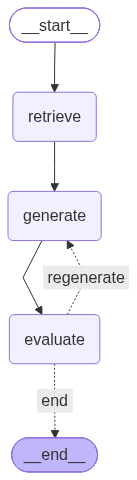

In [10]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> retrieve -> generate -> evaluate")
    print("    evaluate -> generate  (if fail and budget left)")
    print("    evaluate -> END       (if pass or no budget)")

## 11. Test: Normal Question (should pass first try)

In [11]:
print("=" * 60)
print("TEST 1: Straightforward question")
print("=" * 60)
result = app.invoke({
    "query": "What happened when Alice fell down the rabbit hole?",
    "context": "",
    "answer": "",
    "verdict": "",
    "issues": [],
    "iteration": 0,
    "max_iterations": 3,
})
print(f"\nVerdict: {result['verdict']}")
print(f"Iterations: {result['iteration']}")
print(f"Answer: {result['answer'][:400]}")

TEST 1: Straightforward question
  [retrieve] 4 chunks fetched


  [generate] attempt 1, answer length: 410


  [evaluate] verdict: fail | issues: 2
    - The answer adds information absent from the context by mentioning Alice following the White Rabbit and seeing it pop down a rabbit-hole under the hedge, which is not present in chunk 3.
    - The answer contradicts the context by stating that Alice fell down the rabbit-hole twice (once in chunk 4 and again as she followed the White Rabbit), when in fact the correct sequence of events is only described in chunk 4.
  [router] answer failed, retrying (1/3)


  [generate] attempt 2, answer length: 410


  [evaluate] verdict: fail | issues: 2
    - The answer adds information absent from the context by mentioning Alice following the White Rabbit and seeing it pop down a rabbit-hole under the hedge, which is not present in chunk 3.
    - The answer contradicts the context by stating that Alice fell down the rabbit-hole twice (once in chunk 4 and again as she followed the White Rabbit), when in fact the correct sequence of events is only described in chunk 4.
  [router] answer failed, retrying (2/3)


  [generate] attempt 3, answer length: 410


  [evaluate] verdict: fail | issues: 2
    - The answer adds information absent from the context by mentioning Alice following the White Rabbit and seeing it pop down a rabbit-hole under the hedge, which is not present in chunk 3.
    - The answer contradicts the context by stating that Alice fell down the rabbit-hole twice (once in chunk 4 and again as she followed the White Rabbit), when in fact the correct sequence of events is only described in chunk 4.
  [router] max iterations reached, returning best attempt

Verdict: fail
Iterations: 3
Answer: When Alice fell down the rabbit hole, she didn't consider how she would get out again (chunk 4). As she followed the White Rabbit, she ran across a field and saw it pop down a large rabbit-hole under the hedge (chunk 3). She then fell down the rabbit-hole, which dipped suddenly down so that Alice had not a moment to think about stopping herself before finding herself falling down a very deep well 


## 12. Test: Tricky Question (may trigger correction)

In [12]:
print("=" * 60)
print("TEST 2: Question where the model may hallucinate details")
print("=" * 60)
result = app.invoke({
    "query": "What exact words did Alice say to the Caterpillar when she first met it?",
    "context": "",
    "answer": "",
    "verdict": "",
    "issues": [],
    "iteration": 0,
    "max_iterations": 3,
})
print(f"\nVerdict: {result['verdict']}")
print(f"Iterations: {result['iteration']}")
print(f"Answer: {result['answer'][:400]}")

TEST 2: Question where the model may hallucinate details
  [retrieve] 4 chunks fetched


  [generate] attempt 1, answer length: 217


  [evaluate] verdict: fail | issues: 2
    - The answer contains a factual claim ("there is no mention of Alice meeting the Caterpillar") that is not supported by the context.
    - The answer adds information absent from the context (the existence or non-existence of interactions between Alice and the Caterpillar).
  [router] answer failed, retrying (1/3)


  [generate] attempt 2, answer length: 217


  [evaluate] verdict: fail | issues: 2
    - The answer contains a factual claim ("there is no mention of Alice meeting the Caterpillar") that is not supported by the context.
    - The answer adds information absent from the context (the existence or non-existence of interactions between Alice and the Caterpillar).
  [router] answer failed, retrying (2/3)


  [generate] attempt 3, answer length: 217


  [evaluate] verdict: fail | issues: 2
    - The answer contains a factual claim ("there is no mention of Alice meeting the Caterpillar") that is not supported by the context.
    - The answer adds information absent from the context (the existence or non-existence of interactions between Alice and the Caterpillar).
  [router] max iterations reached, returning best attempt

Verdict: fail
Iterations: 3
Answer: Unfortunately, there is no mention of Alice meeting the Caterpillar in the provided context. The context only mentions Alice's interactions with other characters, such as the door, her own thoughts, and Dinah the cat.


## 13. Inspect the Graph Structure

In [13]:
print("=== Graph Structure ===")
g = app.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print(f"Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'retrieve', 'generate', 'evaluate', '__end__']
Edges:
  __start__ -> retrieve
  evaluate -> __end__
  evaluate -> generate
  generate -> evaluate
  retrieve -> generate


## Summary

Key takeaways:
- Self-correction requires two roles: generator and evaluator.
- The evaluator checks every claim in the answer against the retrieved context.
- Failed evaluations trigger regeneration with the same context (budget aware).
- The iteration guard (max_iterations) ensures the graph always terminates.
- In production, you can improve the evaluator by using a stronger model or
  structured output (Pydantic) instead of regex parsing.